# Training and Fine-Tuning BERT for Classification
## Classfying Goodreads Reviews By Book Genre

By Maria Antoniak, Melanie Walsh, and the [AI for Humanists](https://aiforhumanists.com/) Team

Updated: 2024-11-05
<br></br>

This notebook will demonstrate how users can train and fine-tune a BERT model for classification with the popular HuggingFace `transformers` Python library.

We will fine-tune a BERT model on Goodreads reviews from the [UCSD Book Graph](https://mengtingwan.github.io/data/goodreads.html) with the goal of predicting the genre of the book being reviewed. The genres include:
- poetry
- comics & graphic
- fantasy & paranormal
- history & biography
- mystery, thriller, & crime
- romance
- young adult  

**Basic steps involved in using BERT and HuggingFace:**
1. Divide your data into training and test sets.
2. Encode your data into a format BERT will understand.
3. Combine your data and labels into datset objects.
4. Load the pre-trained BERT model.
5. Fine-tune the model using your training data.
6. Predict new labels and evaluate performance on your test data.



## MLOps Assignment 2 — What Was Added on Top of the Original Tutorial

This notebook is based on the AI-for-Humanists DistilBERT tutorial above, extended with the MLOps components required for this assignment:

1. **Secure credential management** — `HF_TOKEN_1` and `WANDB_API_KEY` are read from **Kaggle Secrets** rather than being hard-coded.
2. **Experiment tracking** — training is logged to **Weights & Biases** (loss, accuracy, F1 per epoch), and the final evaluation report is uploaded as a versioned **W&B Artifact**.
3. **Model registry** — the fine-tuned model and tokenizer are pushed to the **Hugging Face Hub** so they can be pulled by name in downstream inference code, instead of only living in local/Kaggle storage.
4. **A single, non-duplicated training pipeline** — one `TrainingArguments` / `Trainer` definition is used end-to-end (train → save → push → evaluate → log), so the model that gets evaluated, logged, and pushed to the Hub is always the *same* fine-tuned model.

The original tutorial's data loading, baseline model, and misclassification-analysis sections are kept unchanged so the notebook still works as a self-contained teaching example.

<br><br>

## **Import necessary Python libraries and modules**

First, we will import necessary Python libraries and modules. These include as `gdown`, for downloading large files from Google Drive (where we will get our UCSD Goodreads reviews), as well as scikit-learn (`sklearn`) and PyTorch (`torch`), for various machine learning tools.

In [1]:
# Added this for secrets
from kaggle_secrets import UserSecretsClient

print("Initializing Kaggle Secrets Client...")
secrets = UserSecretsClient()

print("Retrieving secrets...")
WANDB_API_KEY = secrets.get_secret('WANDB_API_KEY')
HF_TOKEN_1 = secrets.get_secret('HF_TOKEN_1')

import os

os.environ['WANDB_API_KEY'] = WANDB_API_KEY
os.environ['HF_TOKEN_1'] = HF_TOKEN_1

print("Secrets loaded successfully.")
print(" Environment variables set.")
print(f"WANDB_API_KEY loaded: {'Yes' if WANDB_API_KEY else 'No'}")
print(f"HF_TOKEN_1 loaded: {'Yes' if HF_TOKEN_1 else 'No'}")
print(" Setup cell executed successfully in Kaggle Notebook.")

Initializing Kaggle Secrets Client...
Retrieving secrets...
Secrets loaded successfully.
 Environment variables set.
WANDB_API_KEY loaded: Yes
HF_TOKEN_1 loaded: Yes
 Setup cell executed successfully in Kaggle Notebook.


In [2]:
import torch, os

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU visible to this session.")
    print("-> In Kaggle: Notebook menu -> Settings -> Accelerator -> GPU T4 x2 (or P100),")
    print("   and make sure your weekly GPU quota isn't exhausted.")

# Fail fast instead of hanging later if a secret is missing/empty
assert WANDB_API_KEY, "WANDB_API_KEY secret is empty - add it under Kaggle Add-ons > Secrets"
assert HF_TOKEN_1, "HF_TOKEN_1 secret is empty - add it under Kaggle Add-ons > Secrets"

# Give network calls (HF Hub downloads, wandb) a bounded timeout so a flaky
# connection fails with an error instead of hanging the cell forever.
os.environ.setdefault("HF_HUB_DOWNLOAD_TIMEOUT", "60")
os.environ.setdefault("WANDB_INIT_TIMEOUT", "60")

# Disable the newer "Xet" transfer backend for Hugging Face Hub downloads.
# On some restricted/proxied networks (e.g. Kaggle) the Xet reconstruction/transfer
# endpoints stall at 0% indefinitely even though the main hub API is reachable.
# Forcing the classic HTTPS/CDN download path avoids that hang.
os.environ["HF_HUB_DISABLE_XET"] = "1"

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
!pip3 install -U transformers huggingface_hub wandb scikit-learn
# Uninstall hf_xet AFTER the install above, so it isn't silently pulled back in as a
# dependency of huggingface_hub. Without hf_xet present, huggingface_hub falls back to
# plain HTTPS downloads instead of the Xet transfer backend, which is more reliable on
# throttled/proxied networks like Kaggle's (HF_HUB_DISABLE_XET alone is unreliable on
# some huggingface_hub versions - actually removing the package is the robust fix).
!pip3 uninstall -y hf_xet -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.8/26.8 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 37.4 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.4.3
    Uninstalling hf-xet-1.4.3:
      Successfully uninstalled hf-xet-1.4.3
  Attempting uninstall: click
    Found existing installation: click 8.3.3
    Uninstalling click-8.3.3:
      Success

In [4]:
import os

# Set these BEFORE transformers/huggingface_hub are imported anywhere else in
# this notebook. huggingface_hub reads HF_HUB_DISABLE_XET into an internal
# constant at *import time* -- setting it later (e.g. right before a
# from_pretrained() call, several cells down) has no effect once the module
# has already been imported once in this kernel.
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Sanity check: hf_xet must not be importable, otherwise huggingface_hub can
# still attempt the Xet/CDN transfer path (the source of the 403 Forbidden
# errors seen earlier on Kaggle) regardless of the env var above.
try:
    import hf_xet  # noqa: F401
    print("WARNING: hf_xet is still importable in this kernel. If you hit 403 "
          "errors downloading models later, do Run -> Restart Session, then "
          "Run All from the top -- pip uninstalling a package does not remove "
          "it from an already-running kernel's memory.")
except ImportError:
    print("hf_xet not installed/loaded -- standard HTTPS downloads will be used.")


hf_xet not installed/loaded -- standard HTTPS downloads will be used.


In [5]:
# Basic Python modules
from collections import defaultdict
import random
import pickle

# For downloading large files from Google Drive
# https://github.com/wkentaro/gdown
import gdown

# For working with gzip files
# https://docs.python.org/3/library/gzip.html
import gzip

# For working with JSON files
import json

# For data manipulation and analysis
import pandas as pd
import numpy as np

# For machine learning tools and evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# For deep learning
# https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html
import torch

# For plotting and data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
sns.set(style='ticks', font_scale=1.2)

The HuggingFace [`transformers` Python library](https://huggingface.co/transformers/installation.html) is included in Colab by default now, so we do not need to install it (but this is how you would install it with `pip`).

From `transformers`, we will import modules for `DistilBert`, a *distilled* or smaller version of a BERT model that runs more quickly and uses less computing power. This makes it ideal for those just getting started with BERT.

In [6]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

<br><br>

## **Set parameters and file paths**

In [7]:
# This is the name of the BERT model that we want to use.
# We're using DistilBERT to save space (it's a distilled version of the full BERT model),
# and we're going to use the cased (vs uncased) version.
model_name = 'distilbert-base-cased'

# This is the name of the program management system for NVIDIA GPUs. We're going to send our code here.
# Falls back to CPU automatically if no GPU is attached to this session (avoids a hard crash / silent hang on .to('cuda')).
import torch
device_name = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device_name}")

# This is the maximum number of tokens in any document sent to BERT.
max_length = 512

# This is the name of the directory where we'll save our model. You can name it whatever you want.
cached_model_directory_name = 'distilbert-reviews-genres'

Using device: cuda


<br><br>

## **Load and sample Goodreads data**

In this cell, we create a Python dictionary with each genre and the link to the corresponding UCSD Goodreads review data for that genre.

*If you manually click on any of the URLs, you will be able to download the data for that genre. For example, here's the link for poetry: https://datarepo.eng.ucsd.edu/mcauley_group/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz*

In [8]:
# This is where our target data is hosted on the web. You only need these paths for the book review dataset.

# Source: https://mengtingwan.github.io/data/goodreads.html#datasets

genre_url_dict = {'poetry':                 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz',
                  'children':               'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_children.json.gz',
                  'comics_graphic':         'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_comics_graphic.json.gz',
                  'fantasy_paranormal':     'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_fantasy_paranormal.json.gz',
                  'history_biography':      'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_history_biography.json.gz',
                  'mystery_thriller_crime': 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_mystery_thriller_crime.json.gz',
                  'romance':                'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_romance.json.gz',
                  'young_adult':            'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_young_adult.json.gz'}

Next we loop through this dictionary and use `gdown` to download the Goodreads review data for each genre from Google Drive.

Now we will load the first 100,000 reviews from each link and randomly sample 2,000 reviews.

In [9]:
import requests
# Stream reviews from URL and collect a subset
def load_reviews(url, head=10000, sample_size=2000):
    reviews = []
    count = 0

    response = requests.get(url, stream=True)
    print(response)
    with gzip.open(response.raw, 'rt', encoding='utf-8') as file:
        for line in file:
            d = json.loads(line)
            reviews.append(d['review_text'])
            count += 1

            # Stop if we have reached the 100,000 limit
            if head is not None and count >= head:
                break

    # Return random sample of reviews
    return random.sample(reviews, min(sample_size, len(reviews)))

# Reviews by genre
genre_reviews_dict = {}

# Load reviews for each genre
for genre, url in genre_url_dict.items():
    print(f'Loading reviews for genre: {genre}')
    genre_reviews_dict[genre] = load_reviews(url, head=10000, sample_size=2000)


Loading reviews for genre: poetry
<Response [200]>
Loading reviews for genre: children
<Response [200]>
Loading reviews for genre: comics_graphic
<Response [200]>
Loading reviews for genre: fantasy_paranormal
<Response [200]>
Loading reviews for genre: history_biography
<Response [200]>
Loading reviews for genre: mystery_thriller_crime
<Response [200]>
Loading reviews for genre: romance
<Response [200]>
Loading reviews for genre: young_adult
<Response [200]>


Let's preview a couple of the key-value pairs in `genre_reviews_dict`

In [10]:
for _genre, _reviews in genre_reviews_dict.items():
    print(_genre)
    print(random.sample(_reviews, 1)[0])

poetry
Interesting but ultimately impossible to read clear through. I agree with other reviewers who said Graves' theories are riding the subjective pretty heavily; however, if taken with a grain of salt, his tangents are at least entertaining. 
 Strangely though, as I get older, the less I am willing to blindly get behind people who think anything penis-shaped is bad. That's not to say Graves thinks this, but his book... It's one of those books that a lot of angry-but-fashion-conscious college students will drag their knuckles across, squinting, perhaps twirling their ironic wispy mustaches, proceeding then, of course, to drop references to it in the coolest corner of some patio party all night long. 
 It's a problem.
children
Beautiful illustrations and lovely little childish descriptions.
comics_graphic
This continues the season so far as Angel and Faith are the protectors of Magic Town. This one actually could have been titled "Fred & Faith" as this takes place while Angel was batt

Here we use `pickle` to save this Python dictionary to a `.pickle` file so we can easily load it later.

*The `pickle` module allows you to save and load Python objects like lists and dictionaries.*

In [11]:
pickle.dump(genre_reviews_dict, open('genre_reviews_dict.pickle', 'wb'))
# genre_reviews_dict = pickle.load(open('genre_reviews_dict.pickle', 'rb'))

<br><br>

## **Split the data into training and test sets**

When training a machine learning model, it is necessary to split your training data into two parts: a "training" set and a "test" set.

We will train our BERT model on the "training" set of Goodreads reviews and then we will evaluate how well it is performing by running it on the "test" set of Goodreads reviews that the model has never seen before.

Normally, to tune the hyperparameters, you should also create a "validation" set for tuning, and only use the "test" set once, at the end of all tuning. For simplicity, in this tutorial, we will only using a training and test set.

In [12]:
train_texts = []
train_labels = []

test_texts = []
test_labels = []

for _genre, _reviews in genre_reviews_dict.items():

  _reviews = random.sample(_reviews, 1000) # Use a very small set as an example.

  for _review in _reviews[:800]:
    train_texts.append(_review)
    train_labels.append(_genre)
  for _review in _reviews[800:]:
    test_texts.append(_review)
    test_labels.append(_genre)

Show how many Goodreads reviews and labels we have in each category: 6400 training reviews, 6400 training labels (genres), 1600 test reviews, 1600 test labels (genre)

In [13]:
len(train_texts), len(train_labels), len(test_texts), len(test_labels)

(6400, 6400, 1600, 1600)

Here's an example of a training label and review:

In [14]:
train_labels[0], train_texts[0]

('poetry',
 'When the Moon Takes Over the Dream is a collection of love poetry translated from Croatian into English. I can only imagine how difficult translating poetry, of all the art forms, must be. \n While there is much to admire in the sincerity and feelings expressed here, particularly in the fine poem, After Finding You; many of the remaining poems are marred by the quality of the translation, copy edit and proofreading. \n Poetry requires precision in the choice of language, so every awkward phrase or problem with syntax, as well as copy errors, stand out. With some revisions, this book could sing. \n I received a free copy of this book.')

<br><br>

## **Run a baseline model (logistic regression)**

Here we train and evaluate a simple TF-IDF baseline model using logistic regression.

We find better-than-random performance, even for a very small dataset. We'll see whether BERT can beat this good baseline!

In [15]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

We train a logistic regression model from scikit-learn on the Goodreads training data, and then we use the trained model to make predictions on our Goodreads review test set.

In [16]:
model = LogisticRegression(max_iter=1000).fit(X_train, train_labels)
predictions = model.predict(X_test)

We can use scikit-learn's `classification_report` function to evaluate how well the logistic regression model's predictions match up with the true labels for the Goodreads reviews.

Importantly, we can see that our average scores are above random performance (we have 8 classes, so random performance would be ~0.2).

In [17]:
print(classification_report(test_labels, predictions))

                        precision    recall  f1-score   support

              children       0.60      0.63      0.62       200
        comics_graphic       0.74      0.75      0.74       200
    fantasy_paranormal       0.42      0.32      0.36       200
     history_biography       0.56      0.49      0.52       200
mystery_thriller_crime       0.52      0.51      0.51       200
                poetry       0.61      0.78      0.68       200
               romance       0.57      0.63      0.60       200
           young_adult       0.40      0.38      0.39       200

              accuracy                           0.56      1600
             macro avg       0.55      0.56      0.55      1600
          weighted avg       0.55      0.56      0.55      1600



<br><br>

## **Encode data for BERT**

We're going to transform our texts and labels into a format that BERT (via Huggingface and PyTorch) will understand. This is called *encoding* the data.

Here are the steps we need to follow:

1. The labels&mdash;in this case, Goodreads genres&mdash;need to be turned into integers rather than strings.

2. The texts&mdash;in this case, Goodreads reviews&mdash;need to be truncated if they're more than 512 tokens or padded if they're fewer than 512 tokens. The tokens, or words in the texts, also need to be separated into "word pieces" and matched to their embedding vectors.

3. We need to add special tokens to help BERT:

| BERT special token | Explanation |
| --------------| ---------|
| [CLS] | Start token of every document. |
| [SEP] | Separator between each sentence |
| [PAD] | Padding at the end of the document as many times as necessary, up to 512 tokens |
|  &#35;&#35; | Start of a "word piece" |




Here we will load `DistilBertTokenizerFast` from the HuggingFace library, which will do all the work of encoding the texts for us. The `tokenizer()` will break word tokens into word pieces, truncate to 512 tokens, and add padding and special BERT tokens.

In [18]:
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name) # The model_name needs to match our pre-trained model.

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Here we will create a map of our labels, or Goodreads genres, to integer keys. We take the unique labels, and then we make a dictionary that associates each label/tag with an integer.

**Note:** HuggingFace documentation sometimes refers to "labels" as "tags" but these are the same thing. We use "labels" throughout this notebook for clarity.

In [19]:
unique_labels = set(label for label in train_labels)
label2id = {label: id for id, label in enumerate(unique_labels)}
id2label = {id: label for label, id in label2id.items()}

In [20]:
label2id.keys()

dict_keys(['children', 'romance', 'fantasy_paranormal', 'poetry', 'young_adult', 'history_biography', 'comics_graphic', 'mystery_thriller_crime'])

In [21]:
id2label.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])

Now let's encode our texts and labels!

In [22]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=max_length)

train_labels_encoded = [label2id[y] for y in train_labels]
test_labels_encoded  = [label2id[y] for y in test_labels]

**Examine a Goodreads review in the training set after encoding**

In [23]:
' '.join(train_encodings[0].tokens[0:100])

'[CLS] When the Moon Takes Over the Dream is a collection of love poetry translated from Croatian into English . I can only imagine how difficult translating poetry , of all the art forms , must be . While there is much to admire in the sincerity and feelings expressed here , particularly in the fine poem , After Finding You ; many of the remaining poems are marred by the quality of the translation , copy edit and proof ##read ##ing . Poetry requires precision in the choice of language , so every awkward phrase or problem with syntax'

**Examine a Goodreads review in the test set after encoding**

In [24]:
' '.join(test_encodings[0].tokens[0:100])

'[CLS] This book is the ancient Greece for me . The search for the right ways of living , the search for morality , justice and the journey from the old ways to the new ones . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

**Examine the training labels after encoding**

In [25]:
set(train_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

**Examine the test labels after encoding**

In [26]:
set(test_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

<br><br>

## **Make a custom Torch dataset**

Here we combine the encoded labels and texts into dataset objects. We use the custom Torch `MyDataSet` class to make a `train_dataset` object from  the `train_encodings` and `train_labels_encoded`. We also make a `test_dataset` object from `test_encodings`, and `test_labels_encoded`.

In [27]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [28]:
train_dataset = MyDataset(train_encodings, train_labels_encoded)
test_dataset = MyDataset(test_encodings, test_labels_encoded)

**Examine a Goodreads review in the Torch `training_dataset` after encoding**

In [29]:
' '.join(train_dataset.encodings[0].tokens[0:100])

'[CLS] When the Moon Takes Over the Dream is a collection of love poetry translated from Croatian into English . I can only imagine how difficult translating poetry , of all the art forms , must be . While there is much to admire in the sincerity and feelings expressed here , particularly in the fine poem , After Finding You ; many of the remaining poems are marred by the quality of the translation , copy edit and proof ##read ##ing . Poetry requires precision in the choice of language , so every awkward phrase or problem with syntax'

**Examine a Goodreads review in the Torch `test_dataset` after encoding**

In [30]:
' '.join(test_dataset.encodings[1].tokens[0:100])

'[CLS] De ##fin ##ite ##ly complex thoughts that allowed me to dig deeper into my own . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

<br><br>

## **Load pre-trained BERT model**

Here we load a pre-trained DistilBERT model and send it to CUDA.

**Note:** If you decide to repeat fine-tuning after already running the following cells, make sure that you re-run this cell to re-load the original pre-trained model before fine-tuning again.

**If you previously hit `403 Forbidden` errors downloading `distilbert-base-cased` in this same session:** pip installing/uninstalling `hf_xet` again below will *not* fix it on its own. Once a package has been imported in a running kernel, Python keeps it in memory even after `pip uninstall` removes it from disk. Do **Run → Restart Session** (Kaggle) once, then **Run All** from the top, so the `HF_HUB_DISABLE_XET` env var and the absence of `hf_xet` both take effect from the very first import.

In [31]:
import transformers
import huggingface_hub

print("Transformers :", transformers.__version__)
print("HF Hub       :", huggingface_hub.__version__)

import shutil

total, used, free = shutil.disk_usage("/")

print(f"Total : {total/1024**3:.2f} GB")
print(f"Used  : {used/1024**3:.2f} GB")
print(f"Free  : {free/1024**3:.2f} GB")

import requests
import time

t0 = time.time()

r = requests.get("https://huggingface.co", timeout=20)

print("Status:", r.status_code)
print(f"Response time: {time.time()-t0:.2f} seconds")

Transformers : 5.13.1
HF Hub       : 1.23.0
Total : 8062.39 GB
Used  : 6999.14 GB
Free  : 1063.23 GB
Status: 200
Response time: 0.04 seconds


In [32]:
!rm -f /root/.cache/huggingface/token
from huggingface_hub import login
login()
# NOTE: deliberately NOT re-running `pip install -U huggingface_hub transformers`
# here -- that reinstalls hf_xet as a dependency and reintroduces the 403 errors.


In [33]:
!pip uninstall -y hf-xet

In [34]:
import os, shutil, time

os.environ["HF_HUB_DISABLE_XET"] = "1"

cache_path = os.path.expanduser("~/.cache/huggingface/hub/models--distilbert-base-cased")
shutil.rmtree(cache_path, ignore_errors=True)

print(f"Downloading/loading '{model_name}' from the Hugging Face Hub ...")
_t0 = time.time()

from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    use_safetensors=True,
    num_labels=len(label2id),   # <-- 8 genres, not the default 2
    id2label=id2label,          # <-- also lets predictions/config carry genre names
    label2id=label2id,
)
model = model.to(device_name)

print(f"Model loaded and moved to '{device_name}' in {time.time() - _t0:.1f}s")

Downloading/loading 'distilbert-base-cased' from the Hugging Face Hub ...


config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded and moved to 'cuda' in 2.2s


<br><br>

## **Set the BERT fine-tuning parameters**

These are the arguments we'll set in the HuggingFace TrainingArguments objects, which we'll then pass to the HuggingFace Trainer object. There are many more possible arguments, but here we highlight the basics and some common gotchas.

When training your own model, you should search over these parameters to find the best settings for your particular dataset. You should use a held-out set of validation data for this step.

| Parameter | Explanation |
|-----------| ------------|
| num_train_epochs | total number of training epochs (how many times to pass through the entire dataset; too much can cause overfitting) |
| per_device_train_batch_size | batch size per device during training |
| per_device_eval_batch_size |  batch size for evaluation |
|  warmup_steps |  number of warmup steps for learning rate scheduler (set lower because of small dataset size) |
| weight_decay | strength of weight decay (reduces size of weights, like regularization) |
| output_dir | output directory for the fine-tuned model and configuration files |
| logging_dir | directory for storing logs |
| logging_steps | how often to print logging output (so that we can stop training early if the loss isn't going down) |
| evaluation_strategy | evaluate while training so that we can see the accuracy going up |

### Weights & Biases experiment tracking

We log this fine-tuning run to a single W&B run for the rest of the notebook: training metrics (via `report_to="wandb"` in `TrainingArguments` below), the final evaluation report, and a link to the pushed Hugging Face model.

In [35]:
import wandb

WANDB_PROJECT = "mlops-assignment2"
WANDB_RUN_NAME = "distilbert-run-1"
HF_MODEL_NAME = "distilbert-goodreads-genres"  # Hub repo will be <your-hf-username>/<this>

# Authenticate explicitly so this also works in non-interactive Kaggle sessions.
# If login/init fails or times out (bad key, wandb.ai unreachable, etc.), fall back
# to WANDB_MODE=offline instead of hanging the cell — you can still sync the run
# later with `wandb sync`, and the rest of the notebook (training/eval/HF push) is unaffected.
wandb_enabled = True
try:
    wandb.login(key=WANDB_API_KEY, timeout=30)
    wandb.init(
        project=WANDB_PROJECT,
        name=WANDB_RUN_NAME,
        config={
            "model": model_name,
            "epochs": 3,
            "train_batch_size": 16,
            "eval_batch_size": 32,
            "learning_rate": 3e-5,
            "max_length": max_length,
            "dataset": "UCSD Goodreads (subset)",
            "platform": "Kaggle",
        },
    )
except Exception as e:
    print(f"W&B login/init failed ({e}); continuing with W&B in offline mode.")
    os.environ["WANDB_MODE"] = "offline"
    wandb_enabled = False
    wandb.init(project=WANDB_PROJECT, name=WANDB_RUN_NAME, mode="offline")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: g25ait2020 (g25ait2020-iit-jodhpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.28.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260715_095940-w10qtbmh
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run distilbert-run-1
wandb: ⭐️ View project at https://wandb.ai/g25ait2020-iit-jodhpur/mlops-assignment2
wandb: 🚀 View run at https://wandb.ai/g25ait2020-iit-jodhpur/mlops-assignment2/runs/w10qtbmh


<br><br>

## **Fine-tune the BERT model**

First, we define a custom evaluation function that returns the accuracy. You could modify this function to return precision, recall, F1, and/or other metrics.

In [36]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
    }

Here we define a single `TrainingArguments` object. Training metrics are streamed to the W&B run created above via `report_to="wandb"`.

In [37]:
training_args = TrainingArguments(
    output_dir="./results",              # output directory
    logging_dir="./logs",                # directory for storing logs
    num_train_epochs=3,                  # total number of training epochs
    per_device_train_batch_size=16,      # batch size per device during training
    per_device_eval_batch_size=32,       # batch size for evaluation
    learning_rate=3e-5,                  # initial learning rate for Adam optimizer
    warmup_steps=100,                    # warmup steps (kept low; small dataset)
    weight_decay=0.01,                   # strength of weight decay
    logging_steps=50,                    # how often to log training metrics
    eval_strategy="epoch",               # evaluate at the end of every epoch
    save_strategy="epoch",               # checkpoint at the end of every epoch
    load_best_model_at_end=True,         # keep the best checkpoint by eval loss
    report_to="wandb",                   # stream metrics to Weights & Biases (safe even if running in offline mode, see above)
    run_name=WANDB_RUN_NAME,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Then we create a HuggingFace `Trainer` object using the `TrainingArguments` object that we created above. We also send our `compute_metrics` function to the `Trainer` object, along with our test and train datasets.

**Note:** This is what we've been aiming for this whole time! All the work of tokenizing, creating datasets, and setting the training arguments was for this cell.

In [38]:
trainer = Trainer(
    model=model,                         # the instantiated Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=test_dataset,           # evaluation dataset (here, our held-out test set)
    compute_metrics=compute_metrics,     # our custom evaluation function (accuracy + F1)
)

Time to finally fine-tune!

Be patient; if you've set everything in Colab to use GPUs, then it should only take a minute or two to run, but if you're running on CPU, it can take hours.

After every 10 steps (as we specified in the TrainingArguments object), the trainer will output the current state of the model, including the training loss, validation ("test") loss, and accuracy (from our `compute_metrics` function).

You should see the loss going down and the accuracy going up. If instead they are staying the same or oscillating, you probably need to change the fine-tuning parameters.

In [39]:
import numpy as np

labels = np.array(train_labels_encoded)   # use the encoded list directly, not train_dataset["labels"]

print("Min label:", labels.min())
print("Max label:", labels.max())
print("Unique labels:", np.unique(labels))
print("num_labels:", model.config.num_labels)

assert labels.max() < model.config.num_labels, (
    f"Label {labels.max()} out of range for model with {model.config.num_labels} classes — "
    "reload the model with num_labels=len(label2id) before training."
)

trainer.train()

Min label: 0
Max label: 7
Unique labels: [0 1 2 3 4 5 6 7]
num_labels: 8


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.644037,2.426180,0.580000,0.573711
2,2.133430,2.231644,0.603750,0.597966
3,1.671861,2.222764,0.609375,0.603855


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=600, training_loss=2.4376815287272136, metrics={'train_runtime': 533.0278, 'train_samples_per_second': 36.021, 'train_steps_per_second': 1.126, 'total_flos': 2543646198988800.0, 'train_loss': 2.4376815287272136, 'epoch': 3.0})

<br><br>

## **Save fine-tuned model**

The following cell will save the model and its configuration files to a directory in Colab. To preserve this model for future use, you should download the model to your computer.

In [40]:
trainer.save_model(cached_model_directory_name)
tokenizer.save_pretrained(cached_model_directory_name)
print(f"Model and tokenizer saved locally to ./{cached_model_directory_name}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved locally to ./distilbert-reviews-genres


<br><br>

## **Push the fine-tuned model to the Hugging Face Hub**

We push the exact model and tokenizer we just saved (i.e., the final fine-tuned model) so it can be reloaded anywhere with `AutoModelForSequenceClassification.from_pretrained(hf_repo_id)`.

In [41]:
from huggingface_hub import login, HfApi

# HF_TOKEN_1 was already loaded from Kaggle Secrets earlier in the notebook
login(token=HF_TOKEN_1)

hf_username = HfApi().whoami(token=HF_TOKEN_1)["name"]
hf_repo_id = f"{hf_username}/{HF_MODEL_NAME}"

model.push_to_hub(hf_repo_id)
tokenizer.push_to_hub(hf_repo_id)

hf_model_url = f"https://huggingface.co/{hf_repo_id}"
wandb.run.summary["huggingface_model"] = hf_model_url
print(f"Model pushed to: {hf_model_url}")

README.md:   0%|          | 0.00/3.80k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


Model pushed to: https://huggingface.co/Archie14/distilbert-goodreads-genres


(Optional) If you've already fine-tuned and saved the model, you can reload it using the following line. You don't have to run fine-tuning every time you want to evaluate.

In [42]:
# trainer = DistilBertForSequenceClassification.from_pretrained(cached_model_directory_name)

<br><br>

## **Evaluate fine-tuned model**

The following function of the `Trainer` object will run the built-in evaluation, including our `compute_metrics` function.

In [43]:
eval_results = trainer.evaluate()
eval_results

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy,F1
1.671861,2.222764,3,0.609375,0.603855


{'eval_loss': 2.222764492034912,
 'eval_accuracy': 0.609375,
 'eval_f1': 0.6038554607551064}

But we might want to do more fine-grained analysis of the model, so we extract the predicted labels.

In [44]:
predicted_results = trainer.predict(test_dataset)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [45]:
predicted_results.predictions.shape

(1600, 8)

In [46]:
predicted_labels = predicted_results.predictions.argmax(-1) # Get the highest probability prediction
predicted_labels = predicted_labels.flatten().tolist()      # Flatten the predictions into a 1D list
predicted_labels = [id2label[l] for l in predicted_labels]  # Convert from integers back to strings for readability

In [47]:
len(predicted_labels)

1600

In [48]:
print(classification_report(test_labels,
                            predicted_labels))

                        precision    recall  f1-score   support

              children       0.67      0.70      0.68       200
        comics_graphic       0.80      0.84      0.82       200
    fantasy_paranormal       0.43      0.42      0.42       200
     history_biography       0.65      0.54      0.59       200
mystery_thriller_crime       0.54      0.64      0.58       200
                poetry       0.71      0.82      0.77       200
               romance       0.63      0.60      0.61       200
           young_adult       0.39      0.32      0.35       200

              accuracy                           0.61      1600
             macro avg       0.60      0.61      0.60      1600
          weighted avg       0.60      0.61      0.60      1600



<br><br>

## **Pull out correct and incorrect classifications for examination**

Let's use our predicted labels for some analysis!

Now that we've fine-tuned and pulled out our predicted labels, the BERT part of this tutorial is done. You can now use the predicted labels in the same way you would use any set of predicted labels from any classification model. We'll show some examples here.

First, let's print out some example predictions that were correct.

Before moving on to manual inspection, we log the final metrics and the full classification report to the same W&B run, so the run history and the pushed model both correspond to this final fine-tuned checkpoint.

In [49]:
import json as _json

print(eval_results)

wandb.log({
    "final/loss": eval_results["eval_loss"],
    "final/accuracy": eval_results["eval_accuracy"],
    "final/f1": eval_results["eval_f1"],
})

# Full per-class report, built from the predictions computed above (no extra forward pass)
report = classification_report(
    test_labels, predicted_labels, output_dict=True
)
with open("eval_report.json", "w") as f:
    _json.dump(report, f, indent=2)

artifact = wandb.Artifact("eval-report", type="evaluation")
artifact.add_file("eval_report.json")
wandb.log_artifact(artifact)

{'eval_loss': 2.222764492034912, 'eval_accuracy': 0.609375, 'eval_f1': 0.6038554607551064}


<Artifact eval-report>

In [50]:
wandb.finish()

wandb: uploading artifact eval-report; updating run metadata
wandb: uploading artifact eval-report
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁▇██
wandb:                 eval/f1 ▁▇██
wandb:               eval/loss █▁▁▁
wandb:            eval/runtime █▅▅▁
wandb: eval/samples_per_second ▁▄▄█
wandb:   eval/steps_per_second ▁▄▄█
wandb:          final/accuracy ▁
wandb:                final/f1 ▁
wandb:              final/loss ▁
wandb:           test/accuracy ▁
wandb:                     +10 ...
wandb: 
wandb: Run summary:
wandb:           eval/accuracy 0.60938
wandb:                 eval/f1 0.60386
wandb:               eval/loss 2.22276
wandb:            eval/runtime 13.2613
wandb: eval/samples_per_second 120.652
wandb:   eval/steps_per_second 1.885
wandb:          final/accuracy 0.60938
wandb:                final/f1 0.60386
wandb:              final/loss 2.22276
wandb:       huggingface_model https://huggingface....
wandb:                     +16 ...
wandb: 
wandb: 🚀 View r

In [51]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label == _predicted_label:
    print('LABEL:', _true_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

LABEL: romance
REVIEW TEXT: 4.5 stars for this M/M second-chance romance. 
 Marco and Jonny met in 7th grade when Jonny moved in ...

LABEL: poetry
REVIEW TEXT: In a series of 27 amusing poems, a young girl follows her parents' suggestion that she investigate a ...

LABEL: comics_graphic
REVIEW TEXT: This is certainly Garth Ennis writing, but here he's creating an intriguing new world of dark super- ...

LABEL: comics_graphic
REVIEW TEXT: see full review @ Katie's Corner ...

LABEL: comics_graphic
REVIEW TEXT: Strangely enough, I'm not a huge DC Comics fan (nothing against them, I just never got into them as  ...

LABEL: children
REVIEW TEXT: If this book didn't mention Christmas is it, I could use it for preschool storytimes. It's a good ta ...

LABEL: children
REVIEW TEXT: While walking in the woods, Bear finds a floppy bunny who seems to be lost. He takes the little fell ...

LABEL: romance
REVIEW TEXT: First of all you just knew this was gonna be good after reading Rule and getting

Now let's print out some misclassifications.

In [52]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label != _predicted_label:
    print('TRUE LABEL:', _true_label)
    print('PREDICTED LABEL:', _predicted_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

TRUE LABEL: comics_graphic
PREDICTED LABEL: children
REVIEW TEXT: Great as usual. ...

TRUE LABEL: young_adult
PREDICTED LABEL: mystery_thriller_crime
REVIEW TEXT: I feel like this entire book was just Shepard's response to all of the critics and reviewers who say ...

TRUE LABEL: romance
PREDICTED LABEL: children
REVIEW TEXT: Aiemminkin luettuja kirjoja nyt yksissa kansissa. Ah, niin idyllista, romanttista homppaa. Taydellis ...

TRUE LABEL: young_adult
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: This is the sequel to The Adoration of Jenna Fox. This tells the story of the two friends that we th ...



Finally, let's create some heatmaps to examine misclassification patterns. We could use these patterns to think about similarities and differences between genres, according to book reviewers.

In [53]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

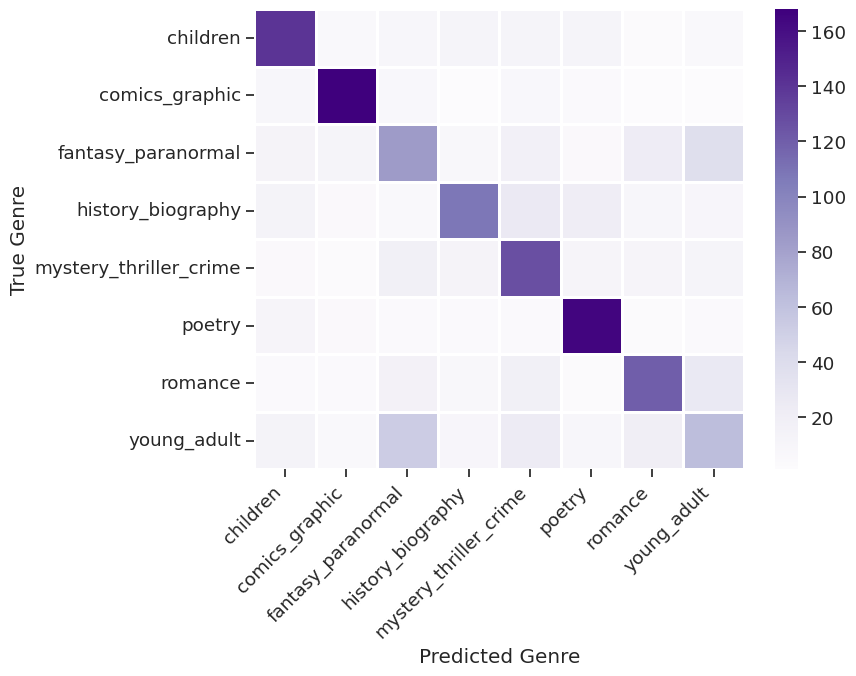

In [54]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Looks good! We can see that overall, our model is assigning the correct labels for each genre.

Now, let's remove the diagonal from the plot to highlight the misclassifications.

In [55]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  if _true_label != _predicted_label: # Remove the diagonal to highlight misclassifications
    genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

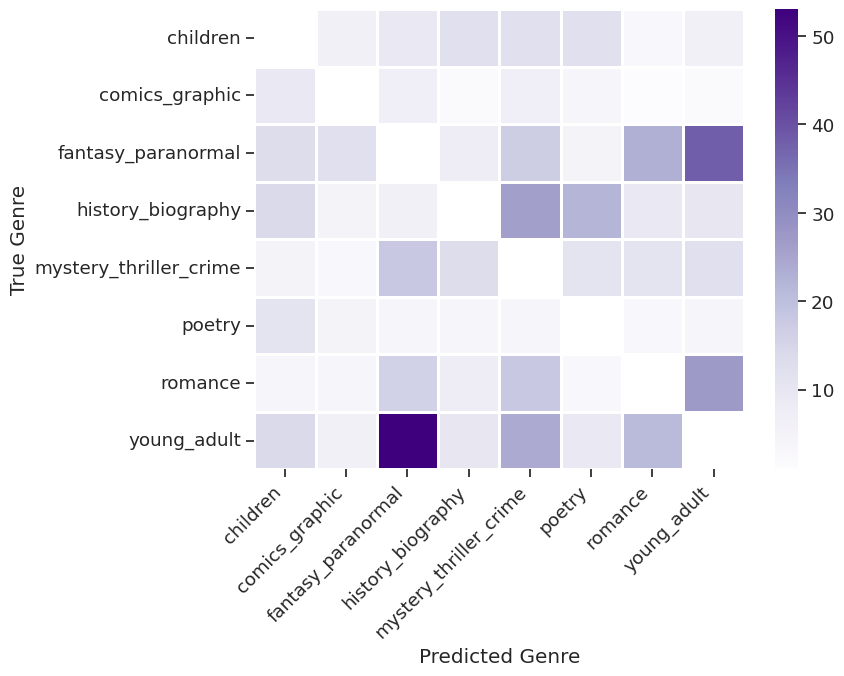

In [56]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

There's much more you can do with your own dataset and labels! Classification can be used to apply a small set of labels across a big dataset; to explore misclassifications to better understand users; and much more! We hope you'll use this tutorial in all kinds of creative ways.

<br><br>

## **Results Summary**

In [57]:
print("MLOps Assignment 2 - Final Results")
print("=" * 40)
print(f"Model:          {model_name}")
print(f"Eval loss:      {eval_results['eval_loss']:.4f}")
print(f"Eval accuracy:  {eval_results['eval_accuracy']:.4f}")
print(f"Eval F1:        {eval_results['eval_f1']:.4f}")
print(f"Hugging Face:   {hf_model_url}")
print(f"W&B project:    {WANDB_PROJECT} (run: {WANDB_RUN_NAME})")

MLOps Assignment 2 - Final Results
Model:          distilbert-base-cased
Eval loss:      2.2228
Eval accuracy:  0.6094
Eval F1:        0.6039
Hugging Face:   https://huggingface.co/Archie14/distilbert-goodreads-genres
W&B project:    mlops-assignment2 (run: distilbert-run-1)
